In [11]:
import Ab as ab
import datetime as dt
import pandas as pd
#use east coast time zone
#sd = dt.datetime(2018,12,28) - dt.timedelta(days=7*14)
#ed = dt.datetime(2019,12,31) + dt.timedelta(days=1)
#sd = dt.datetime(2020,1,3) - dt.timedelta(days=7*15)
#ed = dt.datetime(2020,12,31) + dt.timedelta(days=1)
#sd = dt.datetime(2021,1,1) - dt.timedelta(days=7*15)
#ed = dt.datetime(2021,12,31) + dt.timedelta(days=1)
sd = dt.datetime(2016,1,22) - dt.timedelta(days=200)
ed = dt.datetime(2025,7,18) + dt.timedelta(days=1)

ticker_name = 'TQQQ'

ticker = ab.StockData(ticker_name)
ticker.get_data_from_yfinance(ticker_name,sd,ed+dt.timedelta(days=1))

ffty = ab.StockData('FFTY')
ffty.get_data_from_yfinance('FFTY',sd,ed+dt.timedelta(days=1))

spy = ab.StockData('SPY')
spy.get_data_from_yfinance('SPY',sd,ed+dt.timedelta(days=1))

#set max number of rows to display
pd.set_option('display.max_rows', 1000)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
test_start = dt.datetime(2016,1,22)
test_end = ed
plot_start = dt.datetime(2016,1,22)
plot_end =   ed

In [13]:
#buy and hold
bah = ab.BuyAndHold(ticker)
bah.run_strategy(ticker,test_start,test_end)
bah.trades

,Signal
Date,
2016-01-22,1
2025-07-18,-1


In [14]:

bah_bt = ab.BackTest()
bah_bt.run_backtest(bah,ticker,test_start,test_end)


<Ab.StockData object at 0x7f01446a1ed0>:
cumulative return      : 2330.42%
compound anual return  : 42.5491%
max_drawdown           : -81.02%
sharp_ratio            : 5.31%
average of daily return: 0.2235%
std of daily return    : 4.2073%
number of trades       : 2,
trading days           : 3465,
batting Average        : 100.00%
Gain Average           : 2330.42%
Loss Average           : nan%
Risk Reward Ratio      : nan
Gain STD               : nan%
Loss STD               : nan%
        
    Buy Date            Sell Date Ticker     Quant  Buy Price  Sell Price  \
0 2016-01-22  2025-07-18 00:00:00   TQQQ  0.280164   3.569344       86.75   

      Profit   Profit %  HoldingDays  LongTermProfit  ShortTermProfit  \
0  23.304189  23.304189       3465.0       23.304189              0.0   

   TaxCollectYear  TaxCollected  
0          2026.0           0.0  


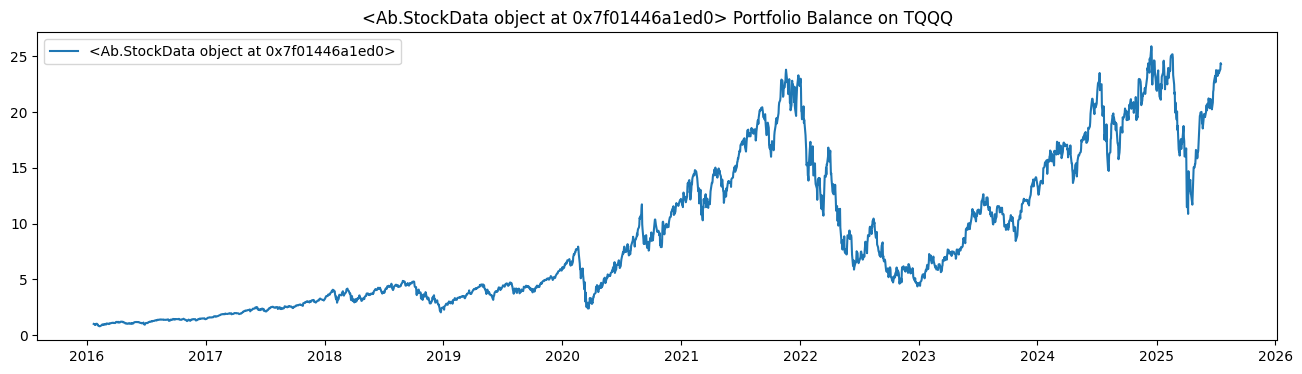

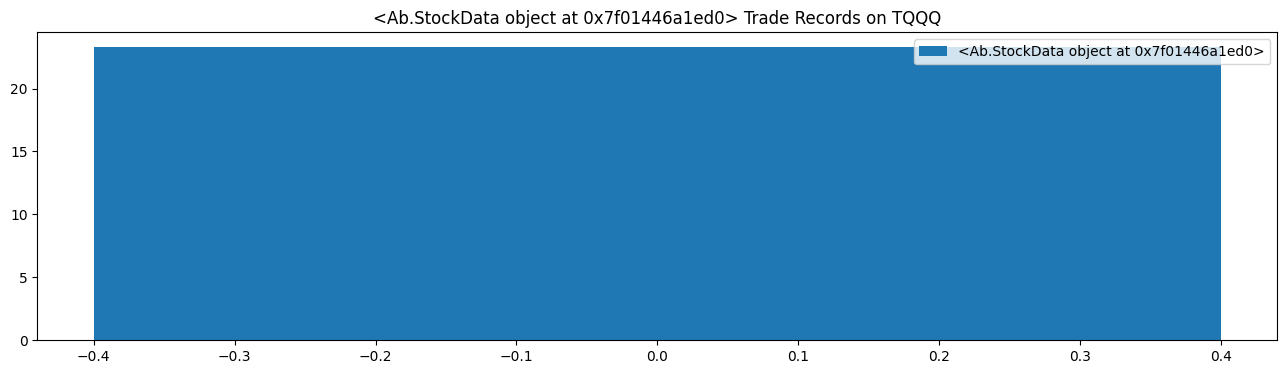

In [15]:

bah_bt.plot_balance()
bah_bt.plot_records()
bah_bt.performance_summary()
print(bah_bt.trade_records)

In [16]:
stg = ab.fftyspy_stg(ffty_sell_threshold = 0.95, ffty_buy_threshold = 1.02,
                                            spy_consecutive_buy_threshold = 1, spy_consecutive_days = 20,
                                            spy_max_off_new_high_pct = -0.2)
stg.run_strategy([ffty,spy], test_start, test_end)


In [17]:

stg_bt = ab.BackTest()
stg_bt.run_backtest(stg,ticker,test_start,test_end)



fftyspy_stg:
cumulative return      : 1247.65%
compound anual return  : 33.5084%
max_drawdown           : -59.84%
sharp_ratio            : 5.20%
average of daily return: 0.1526%
std of daily return    : 2.9331%
number of trades       : 10,
trading days           : 3465,
batting Average        : 55.56%
Gain Average           : 119.07%
Loss Average           : -12.72%
Risk Reward Ratio      : 9.36
Gain STD               : 136.10%
Loss STD               : 10.95%
        
    Buy Date            Sell Date Ticker     Quant  Buy Price  Sell Price  \
0 2016-07-08  2018-10-10 00:00:00   TQQQ  0.241846   4.134855   13.344956   
1 2019-04-03  2020-02-27 00:00:00   TQQQ  0.222301  14.518259   18.180166   
2 2020-05-26  2021-12-13 00:00:00   TQQQ  0.213651  18.916288   76.859261   
3 2022-08-16  2023-04-04 00:00:00   TQQQ  0.443087  37.060482   26.938835   
4 2023-04-11  2023-04-25 00:00:00   TQQQ  0.458605  26.027302   24.436960   
5 2023-06-06  2023-09-21 00:00:00   TQQQ  0.313534  35.743900   

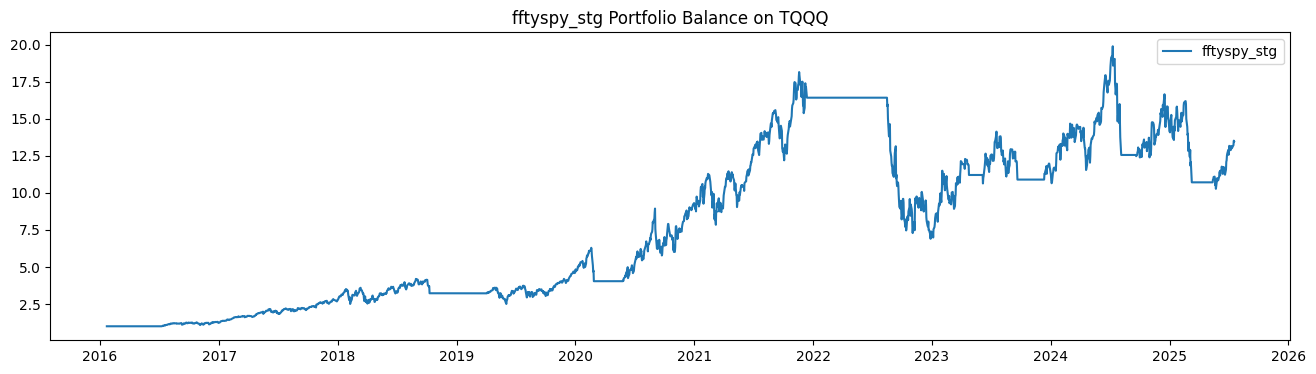

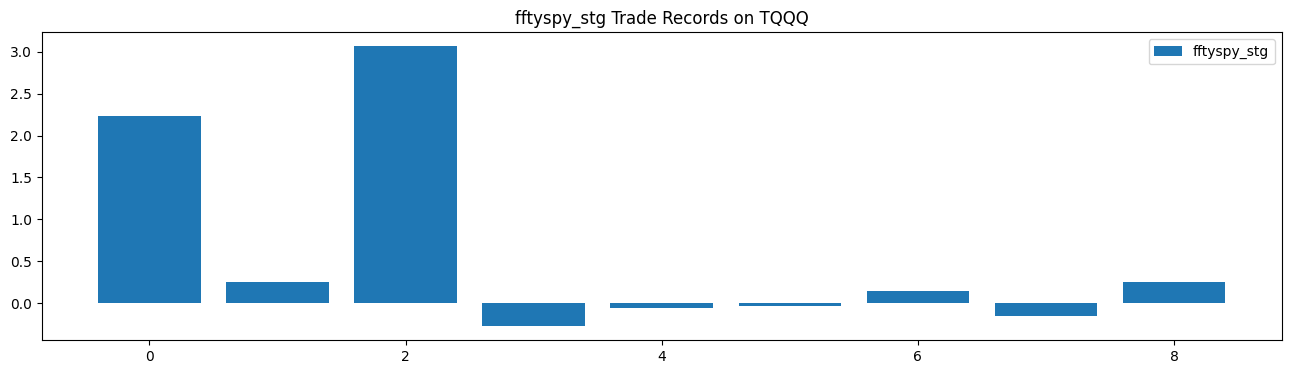

In [18]:
stg_bt.plot_balance()
stg_bt.plot_records()
stg_bt.performance_summary()
print(stg_bt.trade_records)


Index(['TQQQ', 'Weekday', 'Signal', 'BSignal', 'SSignal', 'Cash', 'Stock',
       'Total', 'Margin', 'Trade', 'Buy Price', 'Profit', 'FFTY',
       'FFTY-SMA200', 'FFTY_to_SMA200', 'FFTY_Signal', 'SPY', 'SPY-SMA200',
       'new_high', 'off_new_high', 'max_off_new_high', 'SPY-to-SMA200',
       'SPY-to-SMA200_prev', 'spy-ready-to-buy', 'SPY_Signal'],
      dtype='object', name='Price')
Index(['FFTY', 'FFTY-SMA200', 'FFTY_to_SMA200', 'FFTY_Signal', 'SPY',
       'SPY-SMA200', 'new_high', 'off_new_high', 'max_off_new_high',
       'SPY-to-SMA200', 'SPY-to-SMA200_prev', 'spy-ready-to-buy',
       'SPY_Signal'],
      dtype='object', name='Price')


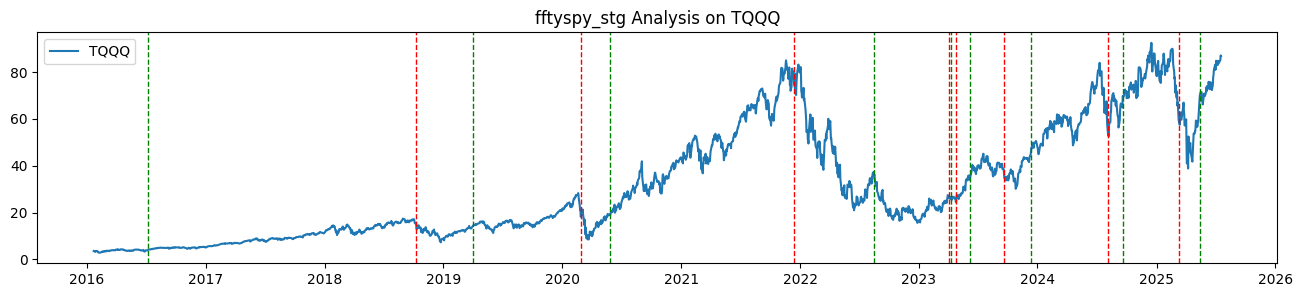

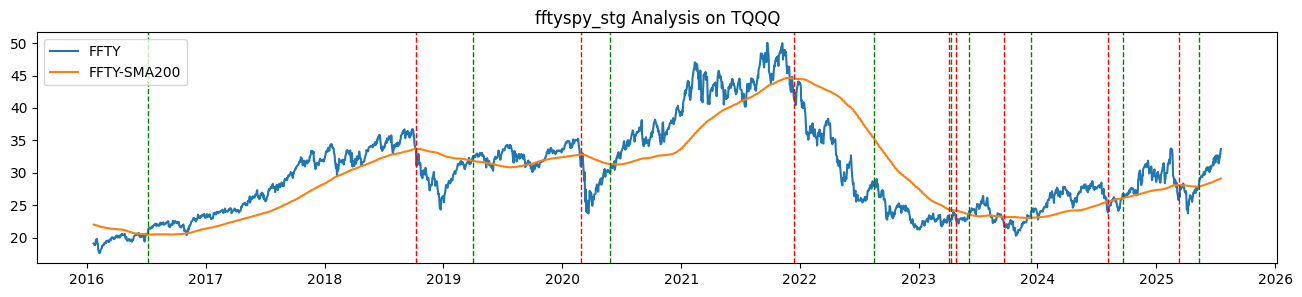

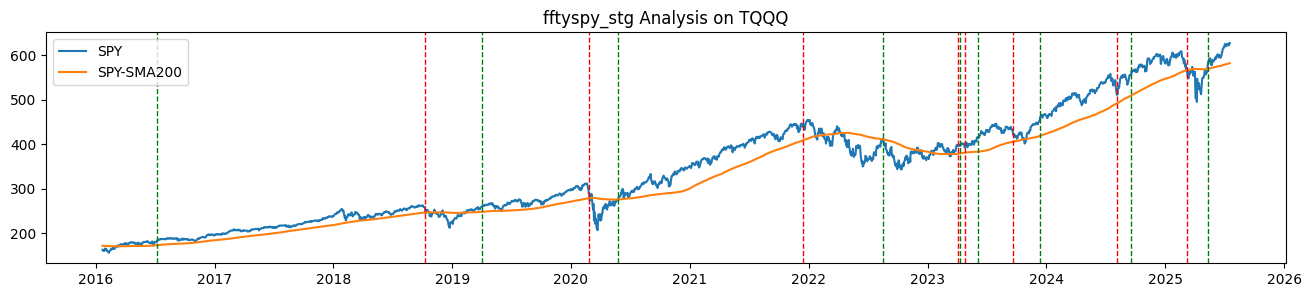

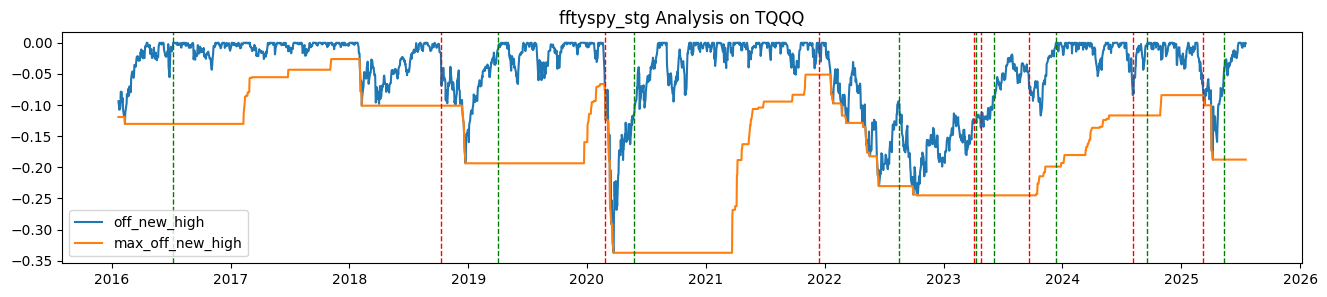

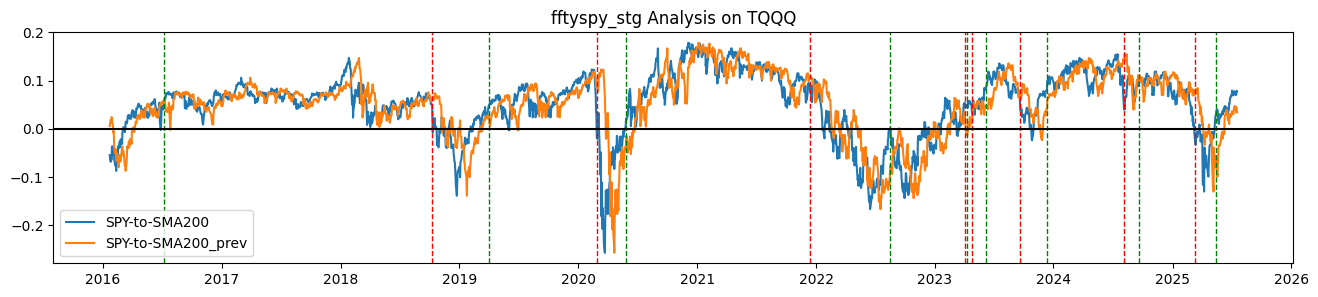

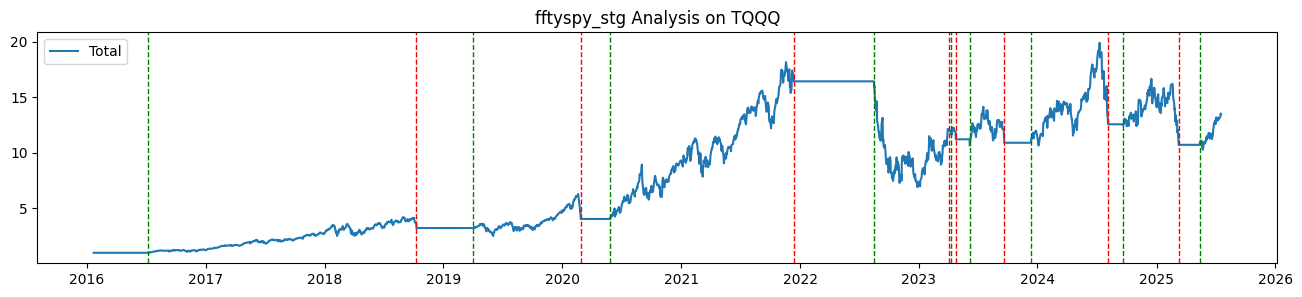

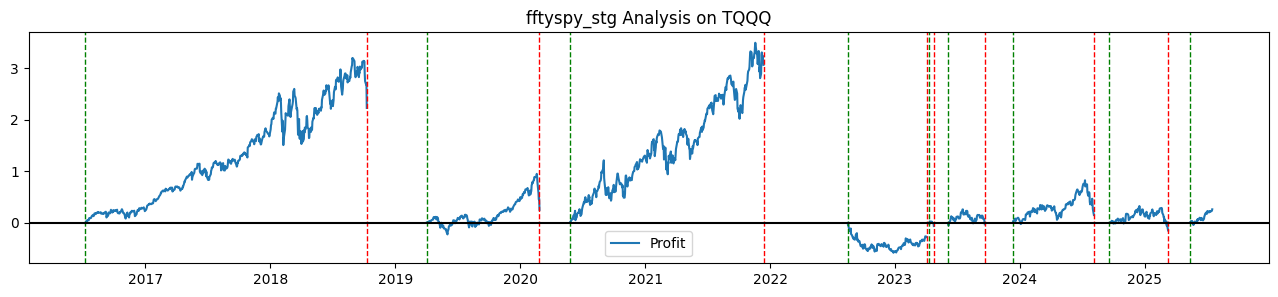

In [19]:
print(stg_bt.joined_data.columns)
print(stg.joined_data.columns)
stg_bt.plot_joined_data([ticker.ticker], plot_start, plot_end)
stg_bt.plot_joined_data(['FFTY', 'FFTY-SMA200'], plot_start, plot_end)
stg_bt.plot_joined_data(['SPY', 'SPY-SMA200'], plot_start, plot_end)
stg_bt.plot_joined_data(['off_new_high', 'max_off_new_high'], plot_start, plot_end)
stg_bt.plot_joined_data(['SPY-to-SMA200','SPY-to-SMA200_prev'], plot_start, plot_end, ydash_low=0)
stg_bt.plot_joined_data(['Total'], plot_start, plot_end)
stg_bt.plot_joined_data(['Profit'], plot_start, plot_end, ydash_low=0)


fftyspy_stg:
cumulative return      : 1605.42%
compound anual return  : 37.0472%
max_drawdown           : -59.84%
sharp_ratio            : 5.54%
average of daily return: 0.1625%
std of daily return    : 2.9350%
number of trades       : 10,
trading days           : 3465,
batting Average        : 66.67%
Gain Average           : 102.36%
Loss Average           : -14.93%
Risk Reward Ratio      : 6.86
Gain STD               : 128.43%
Loss STD               : 12.27%
        
Index(['TQQQ', 'Weekday', 'Signal', 'BSignal', 'SSignal', 'Cash', 'Stock',
       'Total', 'Margin', 'Trade', 'Buy Price', 'Profit', 'FFTY',
       'FFTY-SMA200', 'FFTY_to_SMA200', 'FFTY_Signal', 'SPY', 'SPY-SMA200',
       'new_high', 'off_new_high', 'max_off_new_high', 'SPY-to-SMA200',
       'SPY-to-SMA200_prev', 'spy-ready-to-buy', 'SPY_Signal'],
      dtype='object', name='Price')
Index(['FFTY', 'FFTY-SMA200', 'FFTY_to_SMA200', 'FFTY_Signal', 'SPY',
       'SPY-SMA200', 'new_high', 'off_new_high', 'max_off_new_high'

,Buy Date,Sell Date,Ticker,Quant,Buy Price,Sell Price,Profit,Profit %,HoldingDays,LongTermProfit,ShortTermProfit,TaxCollectYear,TaxCollected
0,2016-07-08,2018-10-10 00:00:00,TQQQ,0.241846,4.134855,13.344956,2.227430,2.227430,824.0,2.227430,0.000000,2019.0,0.0
1,2019-04-03,2020-02-27 00:00:00,TQQQ,0.222301,14.518259,18.180166,0.814047,0.252228,330.0,0.000000,0.814047,2021.0,0.0
2,2020-05-26,2021-12-13 00:00:00,TQQQ,0.213651,18.916288,76.859261,12.379555,3.063126,566.0,12.379555,0.000000,2022.0,0.0
3,2022-08-16,2023-04-04 00:00:00,TQQQ,0.443087,37.060482,26.938835,-4.484774,-0.273112,231.0,0.000000,0.000000,2024.0,0.0
4,2023-06-06,2023-09-21 00:00:00,TQQQ,0.333938,35.743900,34.753223,-0.330825,-0.027716,107.0,0.000000,0.000000,2024.0,0.0
5,2023-11-02,2023-11-16 00:00:00,TQQQ,0.327499,35.436569,42.104115,2.183613,0.188154,14.0,0.000000,2.183613,2024.0,0.0
6,2023-12-12,2024-08-05 00:00:00,TQQQ,0.300022,45.960163,52.965893,2.101871,0.152430,237.0,0.000000,2.101871,2025.0,0.0
7,2024-09-19,2025-03-10 00:00:00,TQQQ,0.227928,69.719002,59.467609,-2.336580,-0.147039,172.0,0.000000,0.000000,2026.0,0.0
8,2025-05-13,2025-07-18 00:00:00,TQQQ,0.196591,68.947006,86.750000,0.000000,0.258213,66.0,0.000000,0.000000,2026.0,0.0


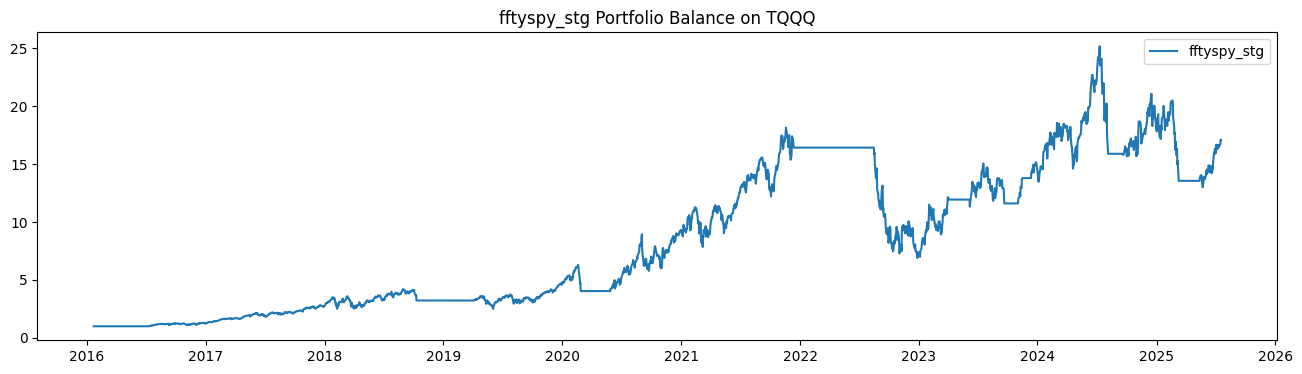

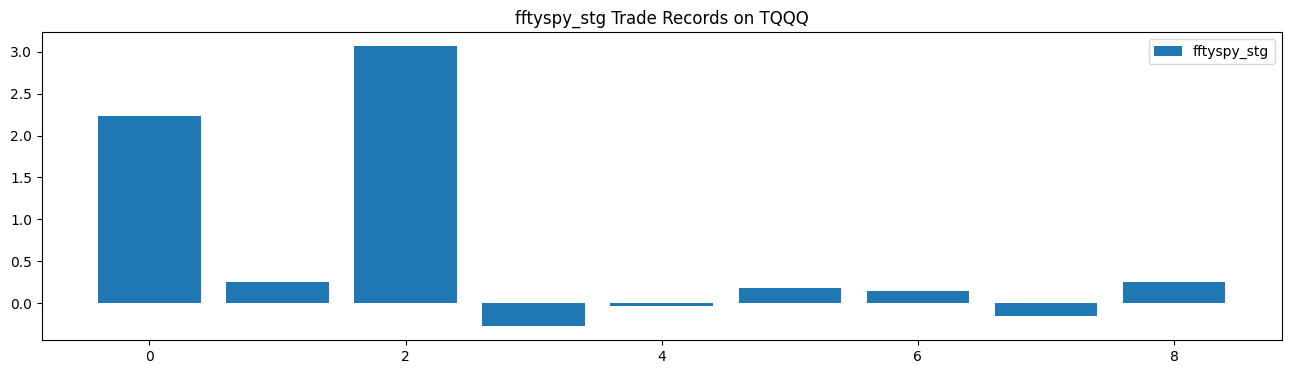

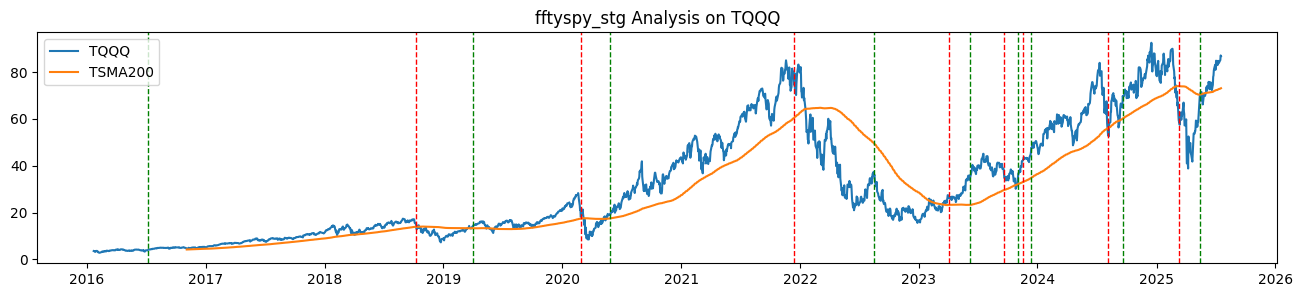

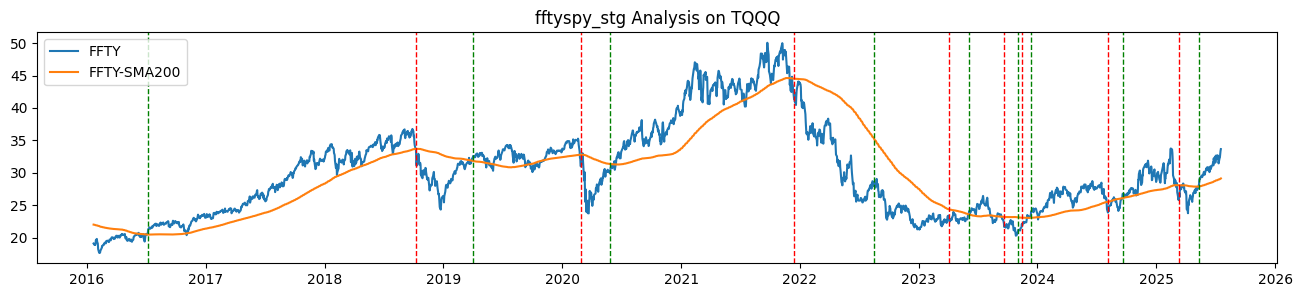

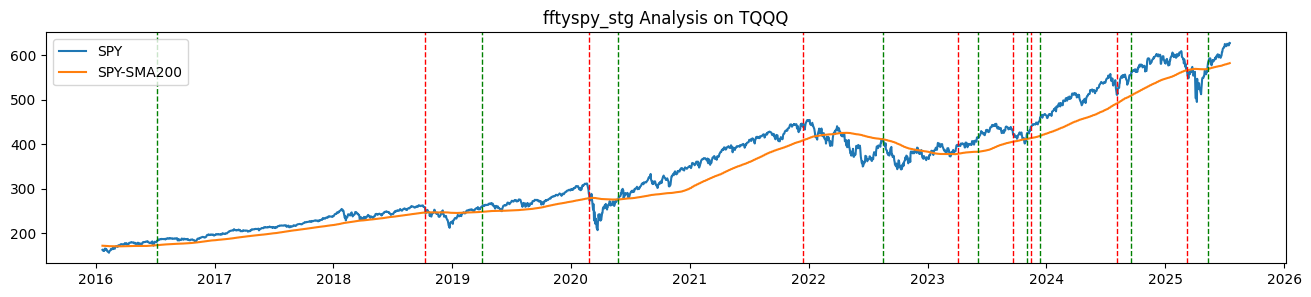

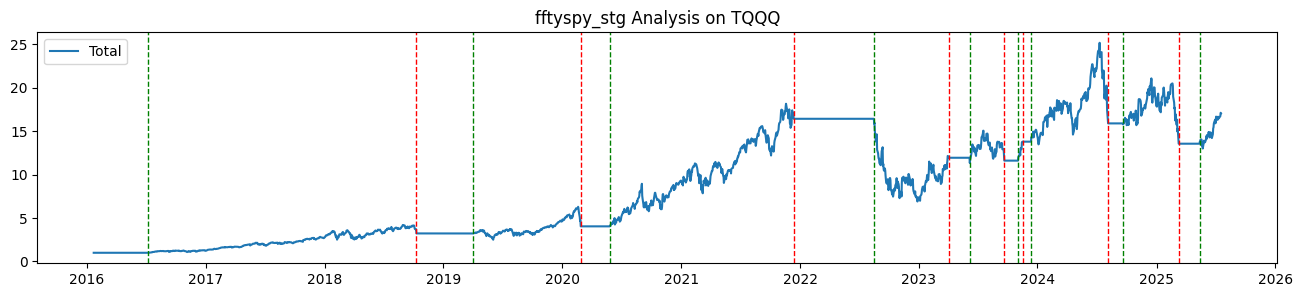

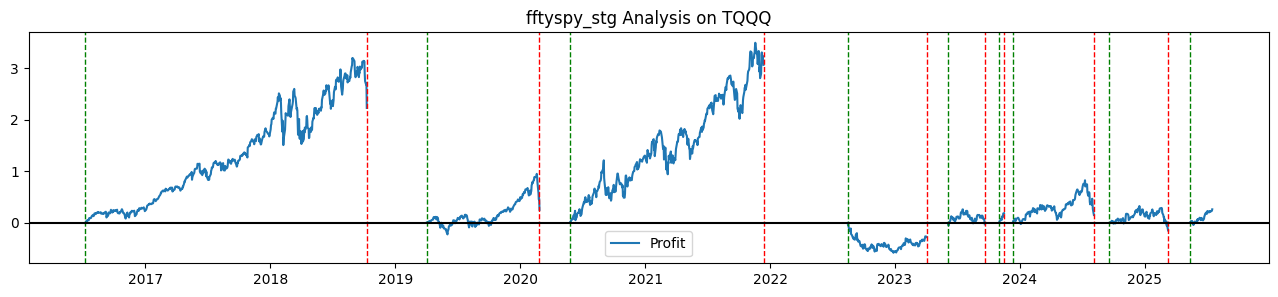

In [20]:

stg = ab.fftyspy_stg(ffty_sell_threshold = 0.95, ffty_buy_threshold = 1.02,
                 spy_consecutive_buy_threshold = 1, spy_consecutive_days = 5,
                 spy_max_off_new_high_pct = -0.2)
stg.run_strategy([ffty,spy], test_start, test_end)
stg_bt = ab.BackTest()
stg_bt.run_backtest(stg,ticker,test_start,test_end)

stg_bt.plot_balance()
stg_bt.plot_records()
stg_bt.performance_summary()

print(stg_bt.joined_data.columns)
print(stg.joined_data.columns)
ab.get_sma(stg_bt.joined_data, ticker.ticker, 'TSMA200', 200)
stg_bt.plot_joined_data([ticker.ticker, 'TSMA200'], plot_start, plot_end)
stg_bt.plot_joined_data(['FFTY', 'FFTY-SMA200'], plot_start, plot_end)
stg_bt.plot_joined_data(['SPY', 'SPY-SMA200',], plot_start, plot_end)
stg_bt.plot_joined_data(['Total'], plot_start, plot_end)
stg_bt.plot_joined_data(['Profit'], plot_start, plot_end, ydash_low=0)
stg_bt.trade_records